In [2]:
import pandas as pd

# Load dataset
df = pd.read_excel(r"C:\Users\itzme\Downloads\Ecommerce.xlsx")

# -------------------------------
# 1. Handling Missing Values
# -------------------------------
print("Missing values:\n", df.isnull().sum())

# Fill numeric columns with median
df['Price'] = df['Price'].fillna(df['Price'].median())
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())

# Fill categorical columns with mode
df['Category'] = df['Category'].fillna(df['Category'].mode()[0])
df['City'] = df['City'].fillna(df['City'].mode()[0])

# Drop rows if critical fields are missing
df.dropna(subset=['OrderID'], inplace=True)

# -------------------------------
# 2. Removing Duplicates
# -------------------------------
df.drop_duplicates(inplace=True)

# -------------------------------
# 3. Correcting Data Types
# -------------------------------
df['OrderDate'] = pd.to_datetime(df['OrderDate'], errors='coerce')
df['Category'] = df['Category'].astype('category')
df['Brand'] = df['Brand'].astype('category')
df['Platform'] = df['Platform'].astype('category')

# -------------------------------
# 4. Creating Derived Columns
# -------------------------------
# TotalAmount = Price × Quantity
df['TotalAmount'] = df['Price'] * df['Quantity']

# Extract Year and Month from OrderDate
df['Year'] = df['OrderDate'].dt.year
df['Month'] = df['OrderDate'].dt.month

# -------------------------------
# 5. Filtering or Aggregating Data
# -------------------------------
# Filter: High-value orders
high_value_orders = df[df['TotalAmount'] > 500]

# Aggregate: Average rating per category
avg_rating = df.groupby('Category')['Rating'].mean()

# Aggregate: Total sales per city
city_sales = df.groupby('City')['TotalAmount'].sum()

print("High-value orders:\n", high_value_orders.head())
print("Average rating per category:\n", avg_rating)
print("Total sales per city:\n", city_sales)


Missing values:
 OrderID        1
Product        1
Category       2
Brand          1
Platform       0
City           1
Price          2
Quantity       1
TotalAmount    0
Rating         0
Reviews        0
OrderDate      1
dtype: int64
High-value orders:
      OrderID             Product     Category    Brand Platform        City  \
0  ORD100000  Samsung Galaxy A14  Electronics  Samsung     Souq       Cairo   
1  ORD100001        Nike Air Max      Fashion     Nike    Jumia  Alexandria   
2  ORD100002   Bluetooth Headset  Accessories      JBL    Jumia  Casablanca   
3  ORD100003  HP Pavilion Laptop    Computers       HP     Souq       Dubai   
4  ORD100004           iPhone 13  Electronics    Apple     Souq  Casablanca   

      Price  Quantity  TotalAmount  Rating  Reviews  OrderDate    Year  Month  
0  16284.02       1.0     16284.02    1.39     1684 2024-11-11  2024.0   11.0  
1   6645.20       2.0     13290.40    2.56     3604 2024-06-22  2024.0    6.0  
2   8882.92       3.0     26648

C:\Users\itzme\AppData\Local\Temp\ipykernel_17536\770023389.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_rating = df.groupby('Category')['Rating'].mean()


count    10000.000000
mean     10025.811849
std       5726.955800
min        105.590000
25%       4999.862500
50%      10062.705000
75%      14935.842500
max      19999.340000
Name: Price, dtype: float64
count    10000.000000
mean         3.006100
std          1.415437
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: Quantity, dtype: float64
count    10000.000000
mean         3.005493
std          1.154825
min          1.000000
25%          2.010000
50%          3.000000
75%          4.000000
max          5.000000
Name: Rating, dtype: float64
Category
Electronics    3029
Fashion        2970
Computers      1952
Accessories    1029
Wearables      1020
Name: count, dtype: int64


Text(0.5, 1.0, 'Orders by Category')

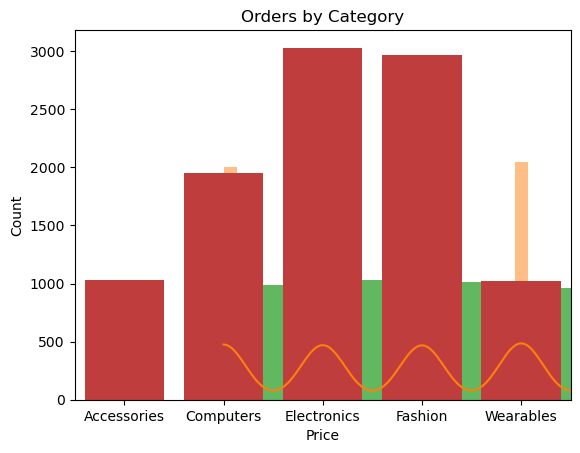

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Price distribution
print(df['Price'].describe())
sns.histplot(df['Price'], bins=30, kde=True)
plt.title("Price Distribution")

# Quantity distribution
print(df['Quantity'].describe())
sns.histplot(df['Quantity'], bins=30, kde=True)
plt.title("Quantity Distribution")

# Ratings distribution
print(df['Rating'].describe())
sns.histplot(df['Rating'], bins=10, kde=False)
plt.title("Ratings Distribution")

# Category frequency
print(df['Category'].value_counts())
sns.countplot(x='Category', data=df)
plt.title("Orders by Category")

                Price  Quantity  TotalAmount    Rating
Price        1.000000  0.006912     0.726875 -0.007529
Quantity     0.006912  1.000000     0.602352  0.000159
TotalAmount  0.726875  0.602352     1.000000  0.000335
Rating      -0.007529  0.000159     0.000335  1.000000


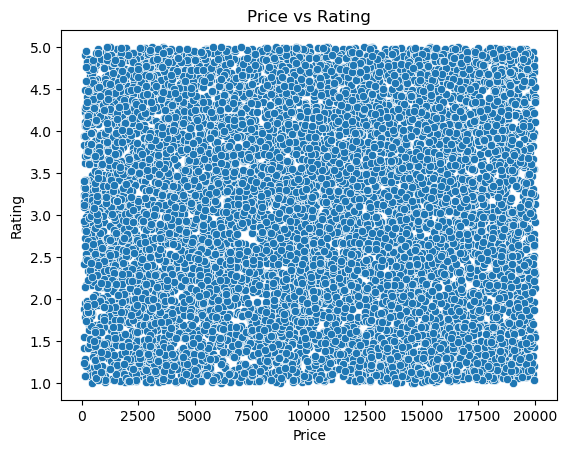

Category
Accessories    28378.007901
Computers      29451.095666
Electronics    30482.421096
Fashion        30812.769246
Wearables      30795.575382
Name: TotalAmount, dtype: float64


C:\Users\itzme\AppData\Local\Temp\ipykernel_17536\686444770.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_sales_category = df.groupby('Category')['TotalAmount'].mean()


In [5]:
# Correlation matrix
print(df[['Price','Quantity','TotalAmount','Rating']].corr())

# Scatter plot: Price vs Rating
sns.scatterplot(x='Price', y='Rating', data=df)
plt.title("Price vs Rating")
plt.show()

# Groupby: Average TotalAmount by Category
avg_sales_category = df.groupby('Category')['TotalAmount'].mean()
print(avg_sales_category)

C:\Users\itzme\AppData\Local\Temp\ipykernel_17536\569274555.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = pd.pivot_table(df, values='TotalAmount', index='Category', columns='City', aggfunc='mean')


City           Alexandria         Cairo    Casablanca         Dubai  \
Category                                                              
Accessories  27888.205109  28325.834696  29799.189545  26717.958476   
Computers    28776.624000  29996.604661  29098.212870  29881.341040   
Electronics  29902.616135  30212.059824  32215.404844  30019.454363   
Fashion      30104.473340  31506.215490  31367.367852  29926.884536   
Wearables    29369.786319  34675.437030  31059.692965  32001.701637   

City                 Giza        Riyadh  
Category                                 
Accessories  28902.236098  28746.028626  
Computers    30827.948939  27971.734587  
Electronics  31908.690877  28760.722898  
Fashion      28640.718872  33175.484404  
Wearables    28341.885000  29493.280175  


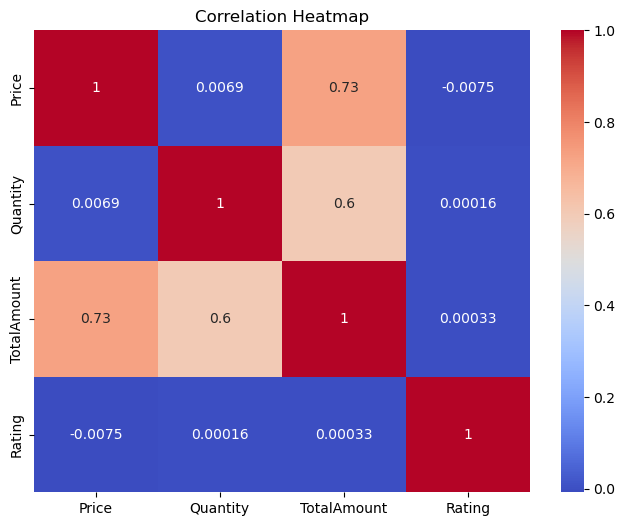

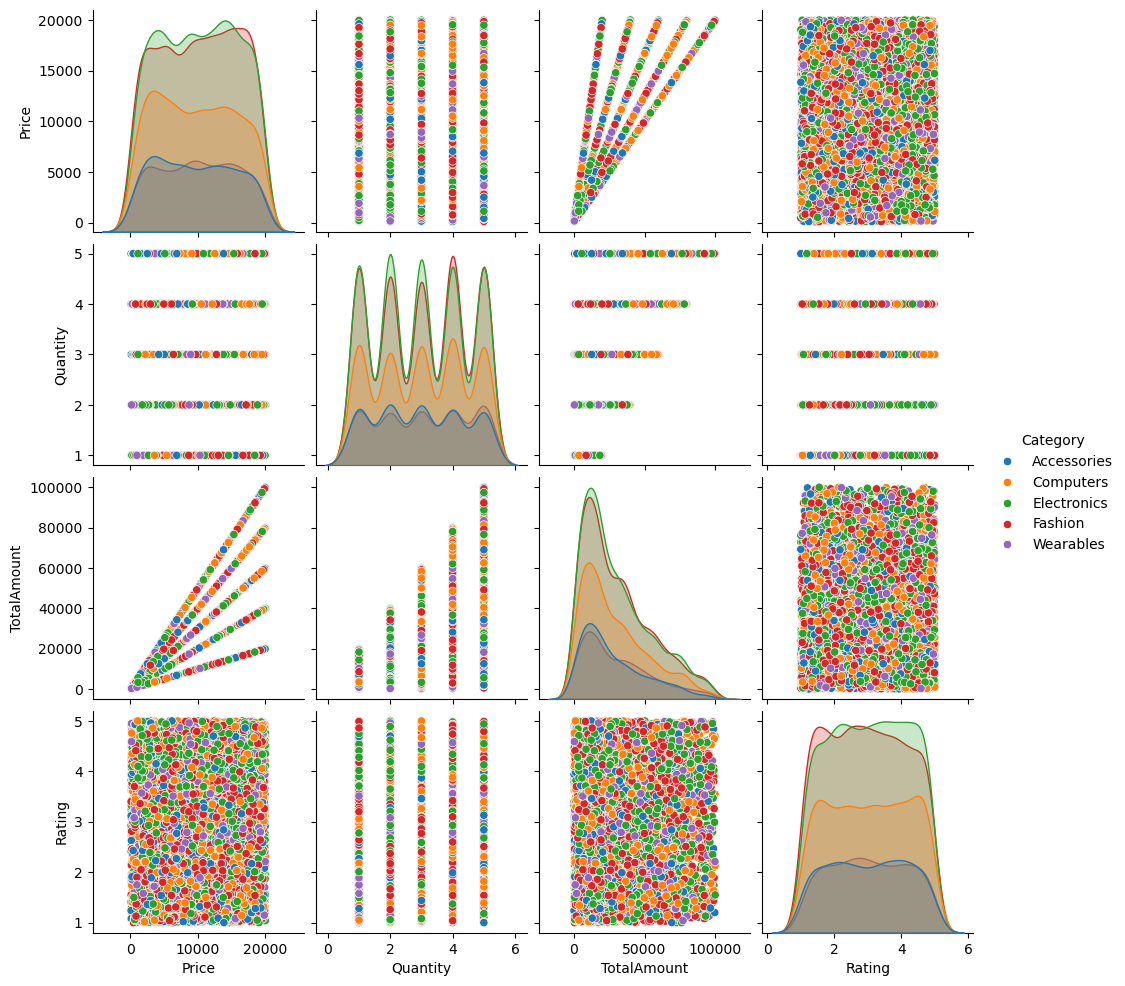

In [7]:

# Pivot table: Average TotalAmount by Category and City
pivot = pd.pivot_table(df, values='TotalAmount', index='Category', columns='City', aggfunc='mean')
print(pivot)

# Heatmap of correlations
plt.figure(figsize=(8,6))
sns.heatmap(df[['Price','Quantity','TotalAmount','Rating']].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Pairplot
sns.pairplot(df[['Price','Quantity','TotalAmount','Rating','Category']], hue='Category')
plt.show()

In [9]:
# City-level sales stats
print(df.groupby('City')['TotalAmount'].agg(['mean','median','std']))

# Category-level rating stats
print(df.groupby('Category')['Rating'].agg(['mean','count','min','max']))

                    mean     median           std
City                                             
Alexandria  29470.706375  22010.180  23245.182004
Cairo       30787.693224  24158.810  24333.031083
Casablanca  30995.804473  24596.245  24659.093102
Dubai       29840.706183  23441.030  23447.656190
Giza        30045.309192  23512.100  23586.800958
Riyadh      29992.906593  23767.300  23824.890861
                 mean  count   min  max
Category                               
Accessories  2.996463   1029  1.00  5.0
Computers    3.030138   1952  1.00  5.0
Electronics  3.030921   3029  1.00  5.0
Fashion      2.958175   2970  1.00  5.0
Wearables    3.029706   1020  1.01  5.0


C:\Users\itzme\AppData\Local\Temp\ipykernel_17536\3674678602.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Category')['Rating'].agg(['mean','count','min','max']))


C:\Users\itzme\AppData\Local\Temp\ipykernel_17536\2582135370.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_sales = df.groupby('Category')['TotalAmount'].sum().sort_values()


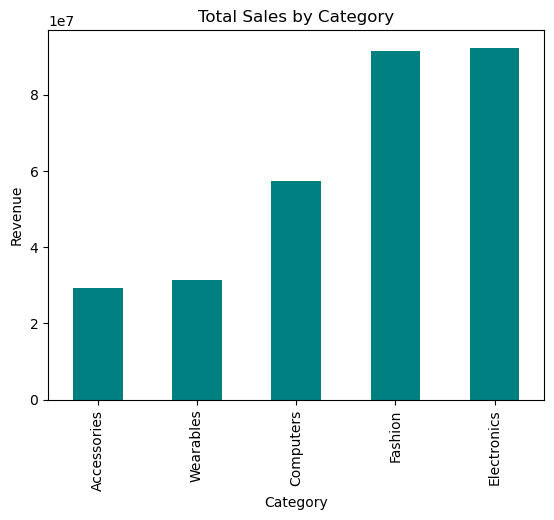

In [10]:
# Bar plot: Total Sales by Category
category_sales = df.groupby('Category')['TotalAmount'].sum().sort_values()
category_sales.plot(kind='bar', color='teal')
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.show()

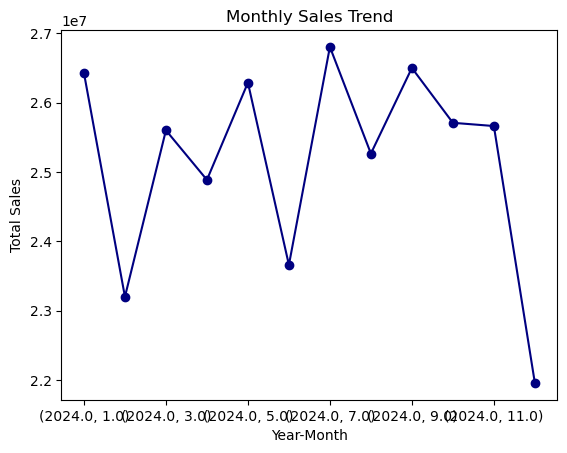

In [11]:
monthly_sales = df.groupby(['Year','Month'])['TotalAmount'].sum()
monthly_sales.plot(kind='line', marker='o', color='navy')
plt.title("Monthly Sales Trend")
plt.xlabel("Year-Month")
plt.ylabel("Total Sales")
plt.show()

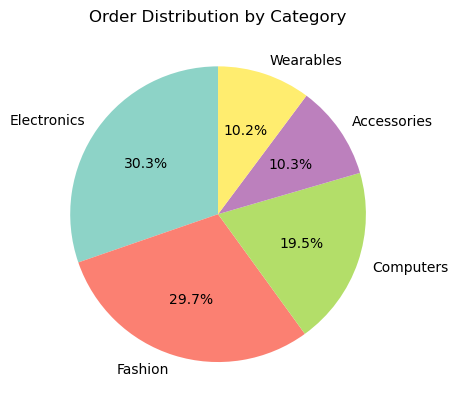

In [12]:
category_counts = df['Category'].value_counts()
category_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, cmap='Set3')
plt.title("Order Distribution by Category")
plt.ylabel("")  # Hide y-label
plt.show()

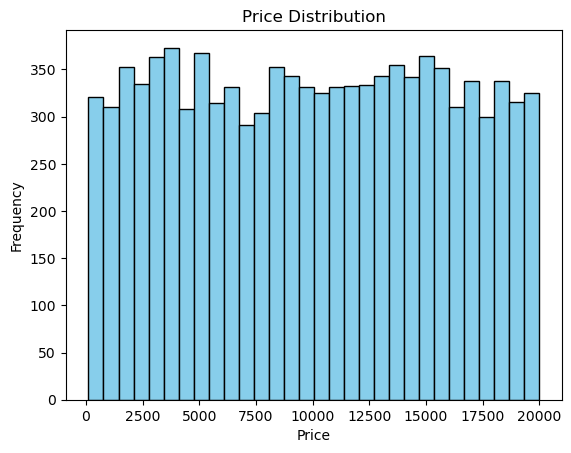

In [13]:
plt.hist(df['Price'], bins=30, color='skyblue', edgecolor='black')
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

C:\Users\itzme\AppData\Local\Temp\ipykernel_17536\2998236664.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='TotalAmount', data=df, palette='Set2')


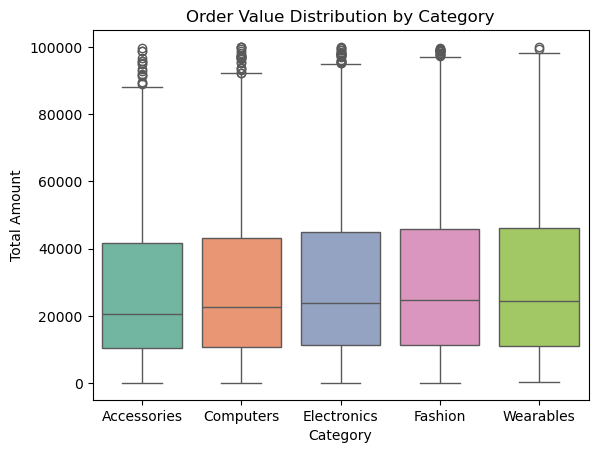

In [14]:
sns.boxplot(x='Category', y='TotalAmount', data=df, palette='Set2')
plt.title("Order Value Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Total Amount")
plt.show()

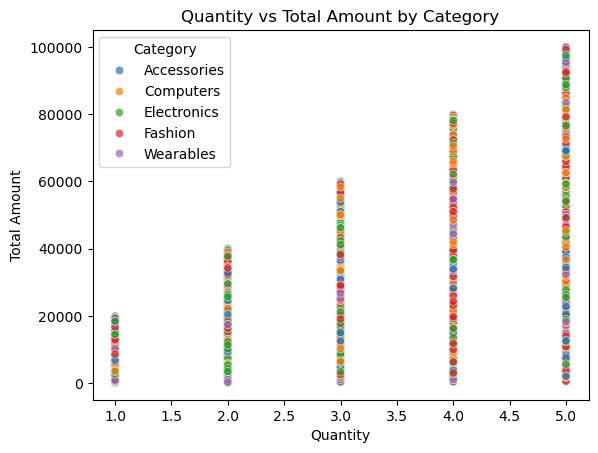

In [15]:
sns.scatterplot(x='Quantity', y='TotalAmount', hue='Category', data=df, alpha=0.7)
plt.title("Quantity vs Total Amount by Category")
plt.xlabel("Quantity")
plt.ylabel("Total Amount")
plt.show()

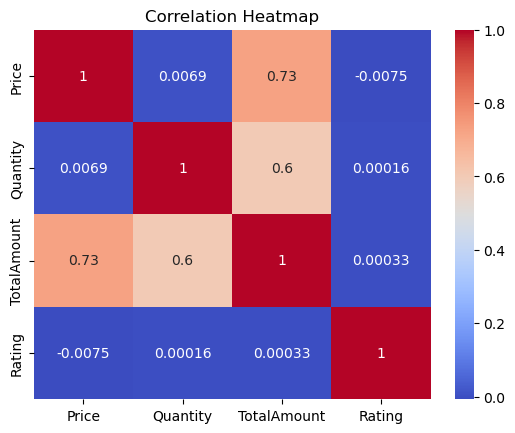

In [16]:
sns.heatmap(df[['Price','Quantity','TotalAmount','Rating']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

C:\Users\itzme\AppData\Local\Temp\ipykernel_17536\3947626572.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='TotalAmount', data=df, ax=axes[1], palette='Set3')


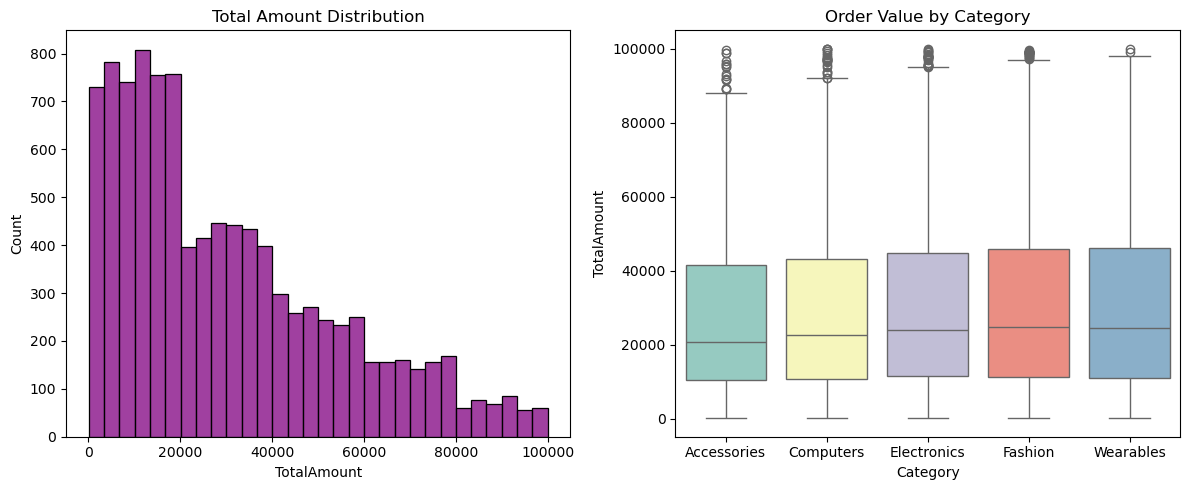

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.histplot(df['TotalAmount'], bins=30, ax=axes[0], color='purple')
axes[0].set_title("Total Amount Distribution")

sns.boxplot(x='Category', y='TotalAmount', data=df, ax=axes[1], palette='Set3')
axes[1].set_title("Order Value by Category")

plt.tight_layout()
plt.show()